# Trader Behavior vs Market Sentiment Analysis

## Objective
This notebook analyzes how trader behavior and performance vary across
different Bitcoin market sentiment regimes (Fear vs Greed). By combining
historical trade-level data with market sentiment indicators, we aim to
understand how profitability, risk-taking, volume, and leverage are
influenced by market emotions.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
sentiment = pd.read_csv('/content/fear_greed_index.csv.csv')
trades = pd.read_csv('/content/historical_data.csv.csv')

In [24]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [26]:
#Cleaning the data set which includes
trades.columns = trades.columns.str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.lower()

trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['timestamp_ist'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

trades = trades[trades['size_usd'] > 0]

In [27]:
#Creating new dataset as 'merged' by extracting all columns of trades and classification and time column from sentiments
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

merged.rename(columns={'classification': 'market_sentiment'}, inplace=True)

In [28]:
#new cleaned and merged dataset of both trades and sentiments
merged


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,market_sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211176,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,Greed
211177,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,Greed
211178,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,Greed
211179,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,Greed


Profitability vs Market Sentiment
### Profitability Analysis
We begin by analyzing how average trader profitability (Closed PnL) varies
across different market sentiment regimes.


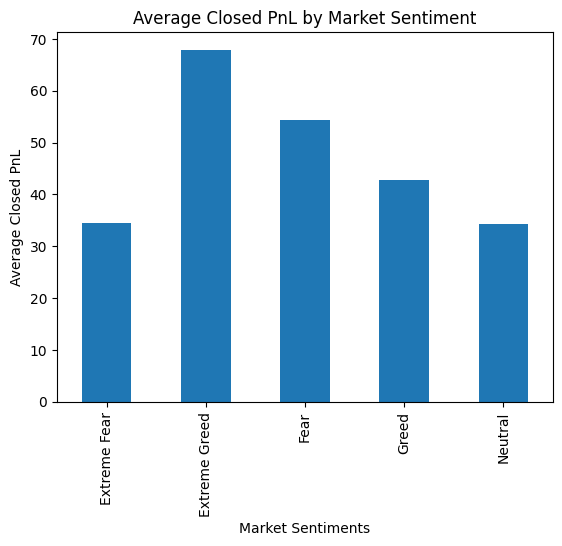

Extreme Greed → Highest average PnL Fear phases also perform well,Neutral & Extreme Fear are weakest


In [29]:
profit_by_sentiment = merged.groupby('market_sentiment')['closed_pnl'].mean().plot(kind='bar')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Market Sentiments')
plt.show()
print("Extreme Greed → Highest average PnL Fear phases also perform well,Neutral & Extreme Fear are weakest")


**Interpretation:**  
Trader profitability varies across sentiment regimes, with emotionally extreme markets showing higher variability in outcomes. This suggests that strong market emotions influence performance, but do not guarantee consistent profits.


Risk & Trade Size Behavior
### Risk-Taking Behavior
Trade size (USD) is used as a proxy for risk exposure. We analyze whether
traders take larger risks during fear or greed-driven market phases.

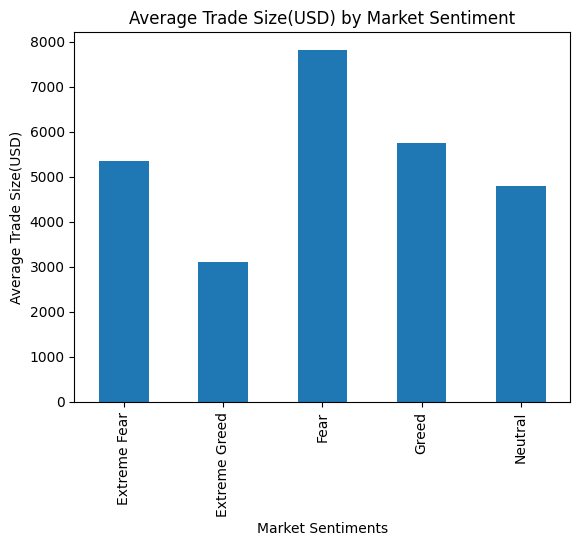

Fear has the highest trade size Extreme Greed trades are smaller but more frequent Indicates cautious sizing despite optimism


In [30]:
risk_by_sentiment = merged.groupby('market_sentiment')['size_usd'].mean().plot(kind='bar')
plt.title('Average Trade Size(USD) by Market Sentiment')
plt.ylabel('Average Trade Size(USD)')
plt.xlabel('Market Sentiments')
plt.show()
print("Fear has the highest trade size Extreme Greed trades are smaller but more frequent Indicates cautious sizing despite optimism")

**Interpretation:**  
Trade sizes tend to increase during fear-driven markets, indicating that traders may take calculated or contrarian risks when market sentiment is pessimistic.


Size Analysis

Volume is used as number of trades by market sentiments

Fear & Greed phases have the most trades Extreme Fear has lowest participation Emotional extremes reduce participation


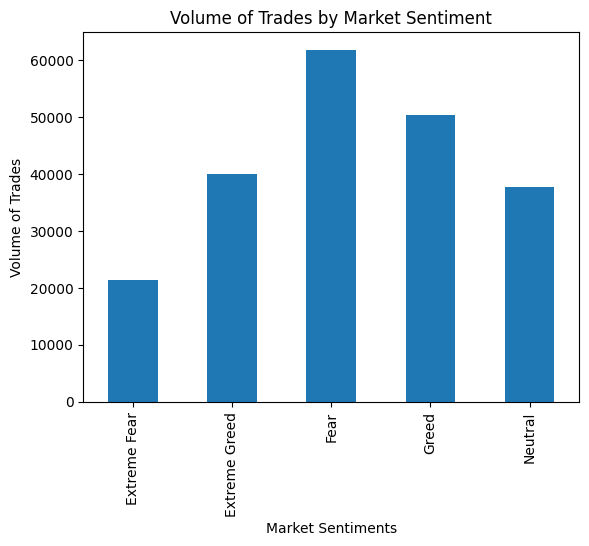

In [31]:
volume_by_sentiment = merged.groupby('market_sentiment').size().plot(kind='bar')
plt.title('Volume of Trades by Market Sentiment')
plt.ylabel('Volume of Trades')
plt.xlabel('Market Sentiments')
print("Fear & Greed phases have the most trades Extreme Fear has lowest participation Emotional extremes reduce participation")

**Interpretation:**  
Trading activity increases during fear and greed phases, while extreme fear is associated with reduced participation, reflecting hesitation and uncertainty among traders.


In [32]:
merged.groupby('market_sentiment')[['size_usd', 'closed_pnl']].mean()

,size_usd,closed_pnl
market_sentiment,,
Extreme Fear,5349.731843,34.537862
Extreme Greed,3113.185707,67.913239
Fear,7817.500563,54.300059
Greed,5739.166214,42.760561
Neutral,4782.732661,34.307718


In [33]:
merged['leverage'] = merged['size_usd'] / merged['size_usd'].median()

Leverage vs Market Sentiment

We analyze whether traders use higher leverage during greed-driven markets compared to fear-driven periods.


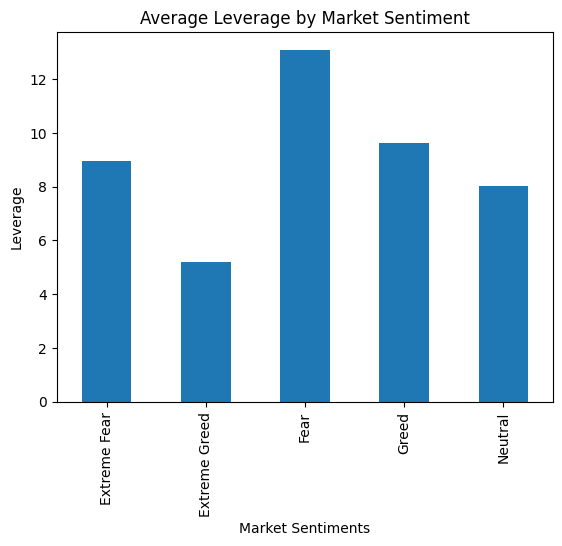

In [34]:
### Average Leverage Across Market Sentiment
print("We analyze whether traders use higher leverage during greed-driven markets compared to fear-driven periods.")
merged.groupby('market_sentiment')['leverage'].mean().plot(kind='bar')
plt.title('Average Leverage by Market Sentiment')
plt.ylabel('Leverage')
plt.xlabel('Market Sentiments')
plt.show()

**Interpretation:**  
Average leverage is higher during greed-driven market phases, suggesting increased risk appetite and confidence when market sentiment is optimistic.


Leverage vs Profitability

This analysis explores whether higher leverage actually translates into better profitability, or if it increases losses.


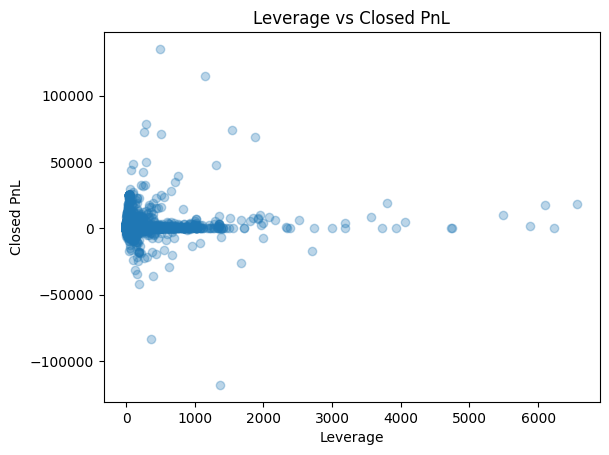

In [35]:
### Leverage vs Profitability
print("This analysis explores whether higher leverage actually translates into better profitability, or if it increases losses.")
plt.scatter(merged['leverage'], merged['closed_pnl'], alpha=0.3)
plt.title('Leverage vs Closed PnL')
plt.xlabel('Leverage')
plt.ylabel('Closed PnL')
plt.show()

**Interpretation:**  
Higher leverage does not consistently result in higher profitability and often leads to more volatile outcomes, highlighting the risk of excessive leverage usage.


Leverage Risk Signal

In [36]:
### High Leverage Risk Signal
print("We compare average profitability under high-leverage and low-leverage trades to identify whether excessive leverage negatively impacts performance.")
merged['leverage_group'] = pd.cut(
    merged['leverage'],
    bins=[0, 5, 10, 20, 50, 100],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Extreme']
)

merged.groupby('leverage_group')['closed_pnl'].mean()


We compare average profitability under high-leverage and low-leverage trades to identify whether excessive leverage negatively impacts performance.


/tmp/ipython-input-146923902.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby('leverage_group')['closed_pnl'].mean()


,closed_pnl
leverage_group,
Very Low,12.168101
Low,78.581107
Medium,123.341265
High,296.722272
Extreme,245.158649


**Interpretation:**  
Moderate leverage levels tend to produce more stable performance, while extremely high leverage amplifies losses, especially during emotionally driven market conditions.


This summary table consolidates key behavioral metrics across sentiment
regimes, highlighting how risk, leverage, and profitability change together.
